# GPU analysis

Purpose: compare CUDA execution across consumer GPUs and distinguish full GPU offload, partial layer offload, and MoE CPU-expert offload.

This notebook reads only `results/processed/final-analysis-dataset.csv` and writes derived figures and tables under `analysis/`. Missing measurements are excluded from the relevant calculation rather than replaced with zero.

In [8]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "analysis").exists():
    PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from analysis.utils import load_dataset, save_figure, save_table, successful, grouped_bar, add_display_hardware

data = load_dataset(PROJECT_ROOT / "results" / "processed" / "final-analysis-dataset.csv")
print(f"Loaded {len(data):,} rows and {len(data.columns):,} columns")

Loaded 630 rows and 37 columns


## GPU analysis subset

Only CUDA rows are included. Successful executions are used for speed, memory, and power summaries; offload categories remain explicit in all summary tables.

In [9]:
gpu = add_display_hardware(data.loc[data["backend"].eq("cuda")].copy())
gpu_success = successful(gpu)
gpu_summary = gpu_success.groupby(["hardware_label", "model", "experiment_category"], as_index=False).agg(decode_tps=("decode_tps", "mean"), prompt_eval_tps=("prompt_eval_tps", "mean"), vram_usage=("vram_usage", "mean"), gpu_power=("gpu_power", "mean"), model_size_b=("model_size_b", "first"))
display(gpu_summary)
save_table(gpu_summary, "03_gpu_performance_summary.csv")
category_summary = gpu_success.groupby("experiment_category", as_index=False).agg(executions=("experiment_id", "size"), hardware=("hardware", "nunique"), models=("model", "nunique"))
display(category_summary)
save_table(category_summary, "03_gpu_offload_category_summary.csv")

,hardware_label,model,experiment_category,decode_tps,prompt_eval_tps,vram_usage,gpu_power,model_size_b
0,GTX 1650 4GB,Qwen3.5-0.8B,gpu_full_offload,99.655556,861.327778,1001.333333,57.324778,0.8
1,GTX 1650 4GB,Qwen3.5-2B,gpu_full_offload,70.588889,390.755556,1444.333333,58.515000,2.0
2,GTX 1650 4GB,Qwen3.5-4B,gpu_full_offload,33.844444,157.172222,3017.000000,60.056667,4.0
3,GTX 1650 4GB,gemma-4-E2B-it,gpu_full_offload,56.433333,276.188889,1694.000000,56.971500,2.0
4,GTX 1660 Super 6GB,Qwen3.5-0.8B,gpu_full_offload,171.138889,1323.716667,1017.333333,96.257556,0.8
5,GTX 1660 Super 6GB,Qwen3.5-2B,gpu_full_offload,131.688889,623.838889,1460.333333,103.110167,2.0
6,GTX 1660 Super 6GB,Qwen3.5-4B,gpu_full_offload,66.727778,247.666667,3032.666667,108.572389,4.0
7,GTX 1660 Super 6GB,Qwen3.5-9B,gpu_full_offload,41.205556,138.005556,5298.666667,109.569889,9.0
8,GTX 1660 Super 6GB,Qwen3.6-35B-A3B,gpu_moe_offload,30.411111,92.916667,5524.333333,73.135667,35.0
9,GTX 1660 Super 6GB,gemma-4-12B-it-QAT,gpu_partial_offload,9.883333,79.177778,5610.333333,53.078500,12.0


,experiment_category,executions,hardware,models
0,gpu_full_offload,270,3,6
1,gpu_moe_offload,69,2,2
2,gpu_partial_offload,36,2,2


WindowsPath('D:/Projects/efficient-llm-inference-research/analysis/tables/03_gpu_offload_category_summary.csv')

## Decode throughput by GPU

The first chart compares mean generation throughput for each GPU/model pair. The underlying summary includes the offload category so full, partial, and MoE offload can be separated in tables.

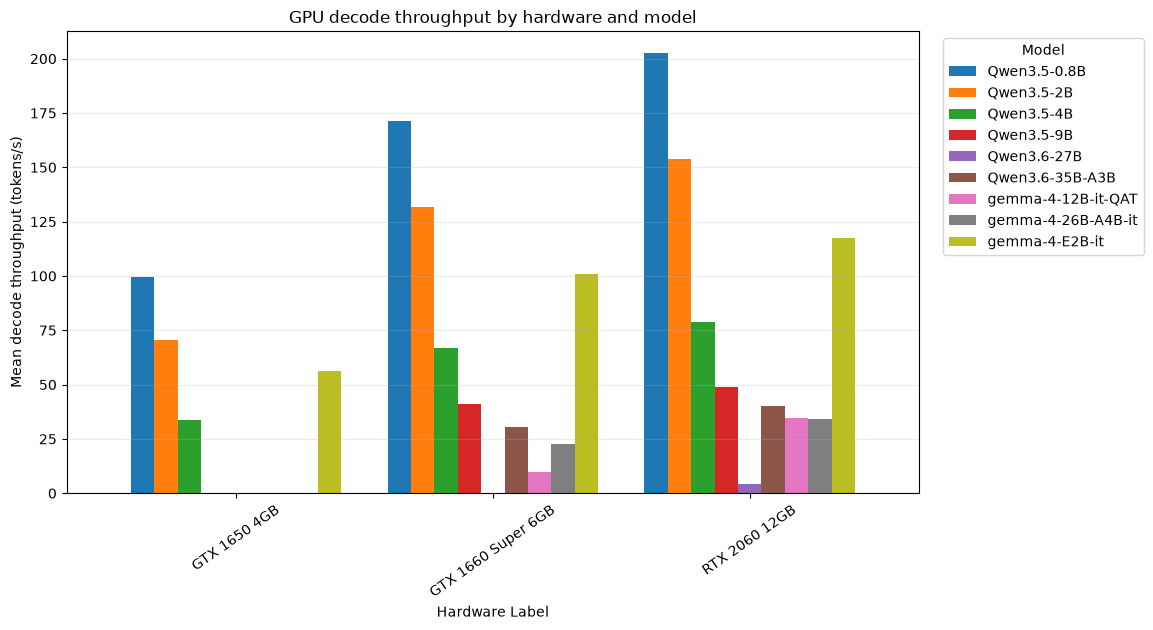

In [10]:
grouped_bar(gpu_success, "hardware_label", "decode_tps", "model", "GPU decode throughput by hardware and model", "Mean decode throughput (tokens/s)", "03_gpu_decode_tps.png", rotate_labels=True)

## Prompt evaluation throughput

Prompt evaluation speed is shown independently because prompt processing and token decoding can respond differently to GPU resources.

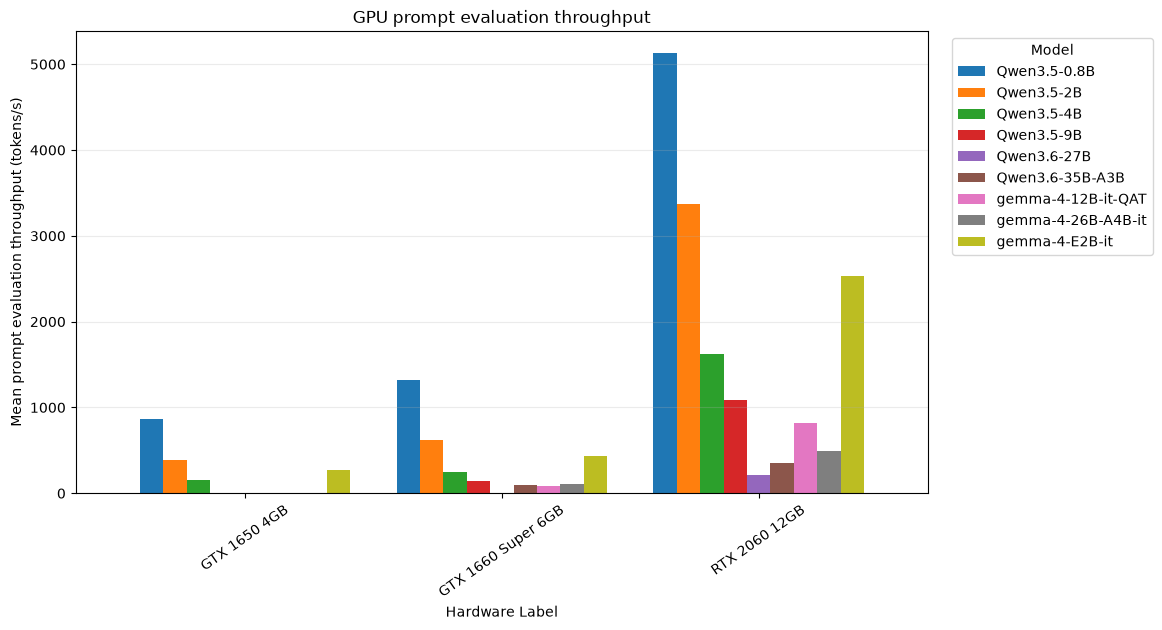

In [11]:
grouped_bar(gpu_success, "hardware_label", "prompt_eval_tps", "model", "GPU prompt evaluation throughput", "Mean prompt evaluation throughput (tokens/s)", "03_gpu_prompt_eval_tps.png", rotate_labels=True)

## VRAM usage versus model size

The scatter plot relates measured VRAM use to nominal model size and uses marker colour for offload category.

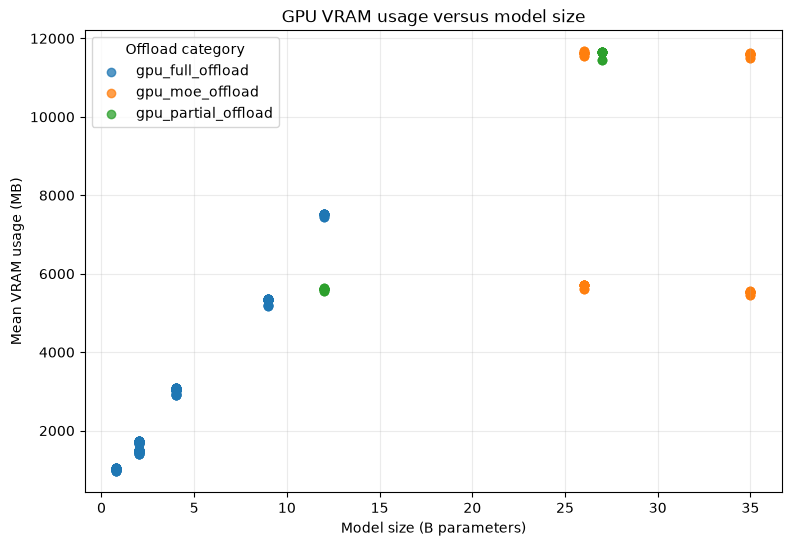

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
for category, subset in gpu_success.dropna(subset=["model_size_b", "vram_usage"]).groupby("experiment_category"):
    ax.scatter(subset["model_size_b"], subset["vram_usage"], label=category, alpha=0.75)
ax.set_title("GPU VRAM usage versus model size")
ax.set_xlabel("Model size (B parameters)")
ax.set_ylabel("Mean VRAM usage (MB)")
ax.legend(title="Offload category")
ax.grid(alpha=0.25)
save_figure(fig, "03_gpu_vram_vs_model_size.png")
plt.show()

## GPU power consumption

Power is compared only where the monitor recorded a value. This avoids treating missing power data as zero consumption.

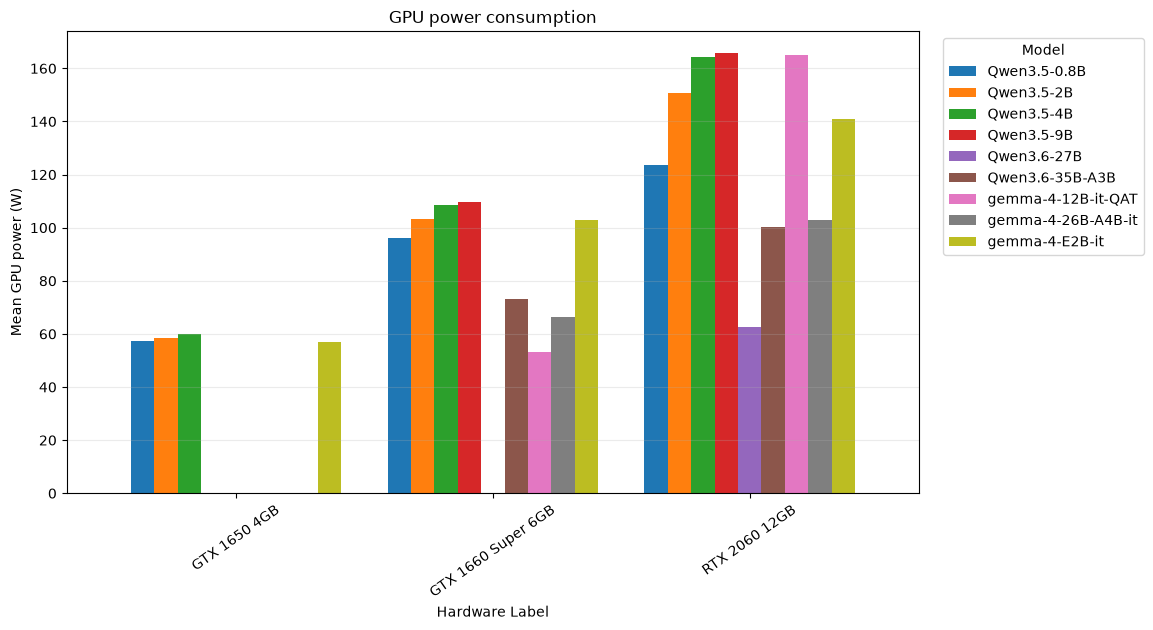

In [13]:
grouped_bar(gpu_success.dropna(subset=["gpu_power"]), "hardware_label", "gpu_power", "model", "GPU power consumption", "Mean GPU power (W)", "03_gpu_power.png", rotate_labels=True)

## Performance per watt

Performance per watt is calculated as decode throughput divided by measured GPU power. It is reported only for positive, non-missing power values.

,hardware_label,model,experiment_category,decode_tps_per_watt,decode_tps,gpu_power
0,GTX 1650 4GB,Qwen3.5-0.8B,gpu_full_offload,1.779412,99.655556,57.324778
1,GTX 1650 4GB,Qwen3.5-2B,gpu_full_offload,1.227829,70.588889,58.515000
2,GTX 1650 4GB,Qwen3.5-4B,gpu_full_offload,0.571516,33.844444,60.056667
3,GTX 1650 4GB,gemma-4-E2B-it,gpu_full_offload,1.011859,56.433333,56.971500
4,GTX 1660 Super 6GB,Qwen3.5-0.8B,gpu_full_offload,1.843617,171.138889,96.257556
5,GTX 1660 Super 6GB,Qwen3.5-2B,gpu_full_offload,1.325840,131.688889,103.110167
6,GTX 1660 Super 6GB,Qwen3.5-4B,gpu_full_offload,0.625846,66.727778,108.572389
7,GTX 1660 Super 6GB,Qwen3.5-9B,gpu_full_offload,0.382870,41.205556,109.569889
8,GTX 1660 Super 6GB,Qwen3.6-35B-A3B,gpu_moe_offload,0.418670,30.411111,73.135667
9,GTX 1660 Super 6GB,gemma-4-12B-it-QAT,gpu_partial_offload,0.186364,9.883333,53.078500


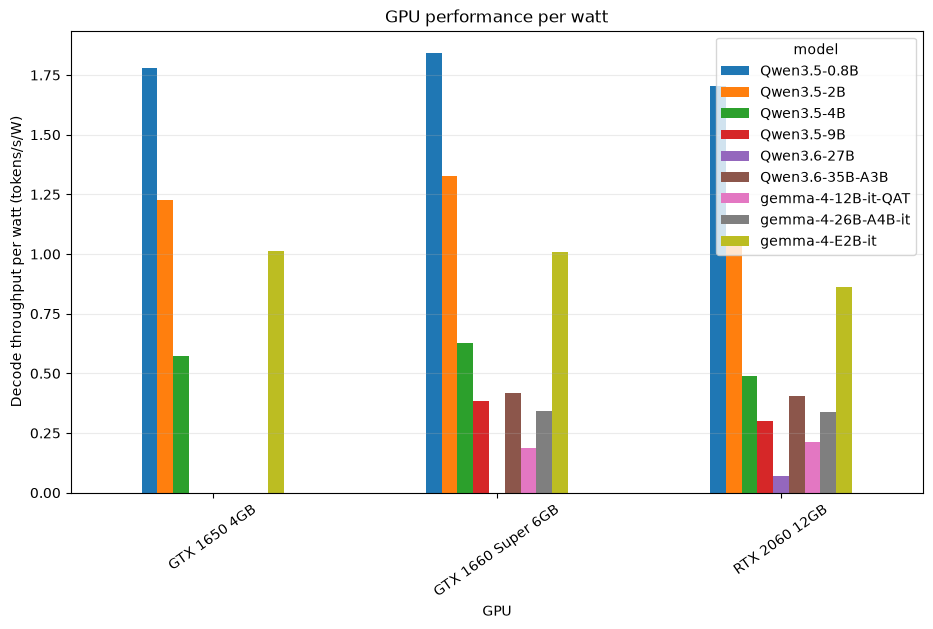

In [14]:
ppw = gpu_success.loc[gpu_success["gpu_power"].gt(0)].copy()
ppw["decode_tps_per_watt"] = ppw["decode_tps"] / ppw["gpu_power"]
ppw_summary = ppw.groupby(["hardware_label", "model", "experiment_category"], as_index=False).agg(decode_tps_per_watt=("decode_tps_per_watt", "mean"), decode_tps=("decode_tps", "mean"), gpu_power=("gpu_power", "mean"))
display(ppw_summary)
save_table(ppw_summary, "03_gpu_performance_per_watt.csv")
fig, ax = plt.subplots(figsize=(11, 6))
ppw_summary.pivot(index="hardware_label", columns="model", values="decode_tps_per_watt").plot(kind="bar", ax=ax)
ax.set_title("GPU performance per watt")
ax.set_xlabel("GPU")
ax.set_ylabel("Decode throughput per watt (tokens/s/W)")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.25)
save_figure(fig, "03_gpu_performance_per_watt.png")
plt.show()